### Applied Deep Learning Project

##### Name: Sayed Saidoo

##### Dataset: DailyDialog

##### Project Overview

This project applies deep learning techniques to the DailyDialog dataset to develop a decoder-only Transformer capable of generating coherent conversational text through autoregressive language modeling. The dataset contains human-written, multi-turn dialogues covering a variety of everyday topics and provides a suitable foundation for learning conversational structure, contextual language patterns, and next-token prediction.

The primary objective of this project is to design, train, and evaluate a GPT-style Transformer model using PyTorch while following a complete deep learning experimentation workflow. The analysis includes dataset inspection, preprocessing, tokenization, model implementation, training, experimental comparison, performance evaluation, and interpretation of generated text outputs.

The study focuses on the following research question:

*Can a compact decoder-only Transformer learn meaningful conversational patterns from human-authored dialogue and generate coherent text continuations while operating within modest computational constraints?*

To address this question, a baseline Transformer model will be trained on the DailyDialog dataset and evaluated using appropriate language modeling metrics and qualitative text generation examples. A controlled comparison experiment will be conducted to investigate the impact of an architectural or hyperparameter modification on model performance.

##### Setup Core Dependencies

In [27]:
import torch
import pandas as pd
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer
from typing import Any
from pathlib import Path
from collections import Counter
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch: 2.14.0+cpu
CUDA Available: False


In [3]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

print(tokenizer.vocab_size)

50257


### Data Ingestion and Inspection

In [4]:
# create path variables for ease of navigation
DATA_PATH = Path("../data/raw/train")

dialogues_path = DATA_PATH / "dialogues_train.txt"
emotion_path = DATA_PATH / "dialogues_emotion_train.txt"
act_path = DATA_PATH / "dialogues_act_train.txt"


In [5]:
with open(dialogues_path, "r", encoding="utf-8") as f:
    dialogues = f.readlines()

with open(emotion_path, "r", encoding="utf-8") as f:
    emotions = f.readlines()

with open(act_path, "r", encoding="utf-8") as f:
    acts = f.readlines()

print(f"Dialogues: {len(dialogues):,}")
print(f"Emotion Labels: {len(emotions):,}")
print(f"Dialogue Acts: {len(acts):,}")


Dialogues: 11,118
Emotion Labels: 11,118
Dialogue Acts: 11,118


In [6]:
# test if dastasets are aligned
assert len(dialogues) == len(emotions) == len(acts)

print("Dataset alignment verified.")

Dataset alignment verified.


In [7]:
# print one conversation
print(dialogues[0])
print(emotions[0])
print(acts[0])

Say , Jim , how about going for a few beers after dinner ? __eou__ You know that is tempting but is really not good for our fitness . __eou__ What do you mean ? It will help us to relax . __eou__ Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ? __eou__ I guess you are right.But what shall we do ? I don't feel like sitting at home . __eou__ I suggest a walk over to the gym where we can play singsong and meet some of our friends . __eou__ That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them . __eou__ Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , too . __eou__ Good.Let ' s go now . __eou__ All right . __eou__

0 0 0 0 0 0 4 4 4 4 

3 4 2 2 2 3 4 1 3 4 



In [8]:
print(type(dialogues))
print(type(emotions))
print(type(acts))

<class 'list'>
<class 'list'>
<class 'list'>


In [9]:
for i in range(3):
    print(f"Conversation {i+1}")
    print(dialogues[i])
    print("-" * 100)

Conversation 1
Say , Jim , how about going for a few beers after dinner ? __eou__ You know that is tempting but is really not good for our fitness . __eou__ What do you mean ? It will help us to relax . __eou__ Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ? __eou__ I guess you are right.But what shall we do ? I don't feel like sitting at home . __eou__ I suggest a walk over to the gym where we can play singsong and meet some of our friends . __eou__ That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them . __eou__ Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , too . __eou__ Good.Let ' s go now . __eou__ All right . __eou__

----------------------------------------------------------------------------------------------------
Conversation 2
Can you do push-ups ? __eou__ Of course I can . It's a piece of cake 

##### Initial Dataset Observations

The DailyDialog training set contains 11,118 human-authored conversations. Each conversation is stored as a single text entry, with individual utterances separated by the special token `__eou__` (End Of Utterance). Separate annotation files provide emotion and dialogue-act labels aligned with each conversation. For the purposes of autoregressive language modeling, the dialogue text corpus will be used as the primary training source, while emotion and dialogue-act annotations are retained as potential extensions for future experimentation.

In [10]:
# Text Statistics
# Utterances per conversation
utterance_counts = [
    conv.count("__eou__")
    for conv in dialogues
]

print("Average utterances:", sum(utterance_counts) / len(utterance_counts))
print("Max utterances:", max(utterance_counts))
print("Min utterances:", min(utterance_counts))

Average utterances: 7.8404389278647235
Max utterances: 35
Min utterances: 2


In [11]:
# Conversation lengths
conversation_lengths = [
    len(conv.split())
    for conv in dialogues
]

print("Average words:", sum(conversation_lengths) / len(conversation_lengths))
print("Max words:", max(conversation_lengths))

Average words: 114.51843856808779
Max words: 868


In [12]:
# Use a generator expression to efficiently count word frequencies
word_counts = Counter(
    word 
    for conversation in dialogues 
    for word in conversation.lower().split()
)

total_words = sum(word_counts.values())
unique_words = len(word_counts)

print(f"Total tokens/words: {total_words:,}")
print(f"Unique vocabulary size: {unique_words:,}")

# Check for rare words
rare_words = sum(1 for word, count in word_counts.items() if count == 1)
print(f"Words that appear exactly once: {rare_words:,} ({(rare_words / unique_words) * 100:.1f}% of vocab)")

# most common tokens
print("\nTop 10 most common tokens:")
print(word_counts.most_common(10))


Total tokens/words: 1,273,216
Unique vocabulary size: 22,076
Words that appear exactly once: 8,704 (39.4% of vocab)

Top 10 most common tokens:
[('.', 98110), ('__eou__', 87170), (',', 46009), ('you', 38840), ('i', 37486), ('?', 33103), ('the', 32224), ('to', 27759), ('a', 23490), ('it', 15980)]


The DailyDialog corpus contains, approximately 1.27 million words and 22,076 unique vocabulary terms. Conversation boundaries are explicitly represented using the __eou__ token, which occurs frequently throughout the dataset and is expected to provide useful turn-level conversational structure for autoregressive language modeling. Possible long tailed distribution here with high proportion (39.4%) appearing only once), will be tested further.

In [13]:
used_token_ids = set()

for conversation in dialogues:
    used_token_ids.update(
        tokenizer.encode(conversation)
    )

gpt_vocab_size = tokenizer.vocab_size
tokens_used = len(used_token_ids)
utilization = (tokens_used / gpt_vocab_size) * 100

print(f"GPT-2 Vocabulary Size: {gpt_vocab_size:,}")
print(f"Unique GPT-2 Tokens Used: {tokens_used:,}")
print(f"Vocabulary Utilization: {utilization:.2f}%")


GPT-2 Vocabulary Size: 50,257
Unique GPT-2 Tokens Used: 19,702
Vocabulary Utilization: 39.20%


When processed using the GPT-2 tokenizer, approximately 19,700 unique GPT-2 token identifiers were observed, representing roughly 39% of the tokenizer's available vocabulary. This suggests that the GPT-2 tokenizer provides meaningful coverage of the conversational language present in the dataset and supports its use as a pretrained tokenization strategy for the baseline model.

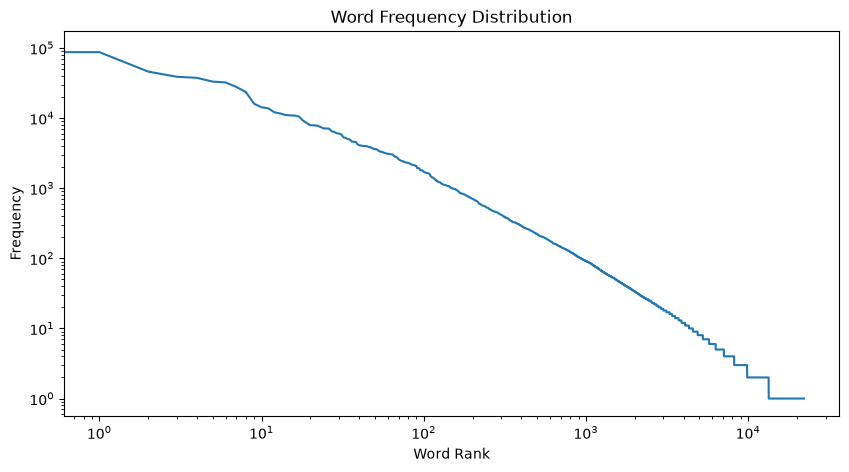

In [14]:
# Zipfs Law to assess frequency distribution for words not token ids
frequencies = sorted(word_counts.values(), reverse=True)
plt.figure(figsize=(10, 5))
plt.plot(frequencies)
plt.yscale("log")
plt.xscale("log")
plt.title("Word Frequency Distribution")
plt.xlabel("Word Rank")
plt.ylabel("Frequency")
plt.show()

The word-frequency distribution exhibits a clear long-tail pattern characteristic of natural language corpora. A relatively small number of highly frequent conversational terms account for a large fraction of the corpus, while many vocabulary items occur infrequently. This behavior is consistent with Zipf's Law and motivates the use of subword tokenization (our gpt tokenizer) to improve the representation of rare terms during training.

##### Summary: Dataset Inspection

The DailyDialog dataset was successfully loaded and inspected to understand its structure, size, and suitability for autoregressive language modeling. The training set contains 11,118 human-authored conversations, with corresponding emotion and dialogue-act annotation files aligned at the conversation level. Each conversation is stored as a single text entry, and individual utterances are separated by the special token `__eou__` (End of Utterance), providing explicit conversational turn boundaries that can be preserved during Transformer training.

Exploratory analysis showed that conversations contain an average of 7.84 utterances, with a maximum of 35 utterances per conversation. Conversations contain an average of 114.5 words, indicating that the dataset provides meaningful conversational context while remaining computationally manageable for a compact Transformer architecture. The dataset consists of approximately 1.27 million words and 22,076 unique vocabulary terms.

Vocabulary analysis revealed a long-tailed distribution characteristic of natural language corpora. Approximately 39.4% of vocabulary terms appear only once, while a small number of highly frequent conversational words account for a large proportion of the dataset. The GPT-2 tokenizer was evaluated as the candidate tokenization strategy and was found to utilize 19,702 unique token identifiers, representing approximately 39.2% of the tokenizer's available vocabulary. This suggests that the GPT-2 tokenizer provides meaningful coverage of the conversational language present in the corpus. However, approximately 60.8% of the GPT-2 vocabulary was not observed within the DailyDialog training corpus. While retaining the full GPT-2 vocabulary simplifies implementation and provides robust subword coverage, future iterations of this project could investigate corpus-specific vocabulary reduction strategies to improve parameter efficiency in the embedding and output projection layers.

The dialogue text data will be our primary datasets used for model training, testing and validation. This data represents the converstional structure required to meet our objective.

### Data Preparation

In [15]:
# Get relevant tokenizer details
print(tokenizer.eos_token)
print(tokenizer.eos_token_id)

<|endoftext|>
50256


In [16]:
# Testing one sample before EOS processing
sample_conversation = dialogues[0].strip() + " " + tokenizer.eos_token

print(sample_conversation[-150:])

ould ask them to go dancing with us.That is excellent exercise and fun , too . __eou__ Good.Let ' s go now . __eou__ All right . __eou__ <|endoftext|>


In [17]:
processed_dialogues = [
    conversation.strip() + " " + tokenizer.eos_token
    for conversation in dialogues
]

print(f"Processed conversations: {len(processed_dialogues):,}")

Processed conversations: 11,118


In [18]:
# tokenize the dialogues to compute the statistics
tokenized_dialogues = [
    tokenizer.encode(conversation)
    for conversation in processed_dialogues
]

print(f"Tokenized conversations: {len(tokenized_dialogues):,}")

Tokenized conversations: 11,118


In [19]:
token_lengths = [
    len(tokens)
    for tokens in tokenized_dialogues
]

print(f"Average token length: {sum(token_lengths)/len(token_lengths):.2f}")
print(f"Maximum token length: {max(token_lengths)}")
print(f"Minimum token length: {min(token_lengths)}")

print(f"Median: {np.median(token_lengths):.0f}")
print(f"95th Percentile: {np.percentile(token_lengths, 95):.0f}")

Average token length: 146.99
Maximum token length: 952
Minimum token length: 15
Median: 129
95th Percentile: 327


A context length of 256 tokens was selected based on the observed token-length distribution of the DailyDialog corpus. While the median conversation length was approximately 129 tokens, the 95th percentile reached 327 tokens. A 256-token context window provides a balance between conversational coverage and computational efficiency while remaining suitable for training on Google Colab hardware.

In [20]:
# continuous stream approach to creating sliding windows
all_tokens = []

for conversation in processed_dialogues:
    all_tokens.extend(
        tokenizer.encode(conversation)
    )

print(f"Total tokens in corpus: {len(all_tokens):,}")

Total tokens in corpus: 1,634,226


In [21]:
print(all_tokens[:20])
print(all_tokens[-20:])

[25515, 837, 5395, 837, 703, 546, 1016, 329, 257, 1178, 16800, 706, 8073, 5633, 11593, 68, 280, 834, 921, 760]
[5633, 11593, 68, 280, 834, 16805, 764, 314, 1183, 655, 307, 257, 5664, 764, 11593, 68, 280, 834, 220, 50256]


In [22]:
print(f"Vocabulary IDs observed: {len(set(all_tokens)):,}")

Vocabulary IDs observed: 19,702


In [23]:
CONTEXT_LENGTH = 256

total_windows = len(all_tokens) - CONTEXT_LENGTH

print(f"Potential training windows: {total_windows:,}")

Potential training windows: 1,633,970


In [24]:
class GPTDialogueDataset(Dataset):

    def __init__(self, token_ids, block_size):
        self.token_ids = token_ids
        self.block_size = block_size

    def __len__(self):
        return len(self.token_ids) - self.block_size

    def __getitem__(self, idx):

        x = torch.tensor(
            self.token_ids[idx : idx + self.block_size],
            dtype=torch.long
        )

        y = torch.tensor(
            self.token_ids[idx + 1 : idx + self.block_size + 1],
            dtype=torch.long
        )

        return x, y

In [25]:
train_dataset = GPTDialogueDataset(
    all_tokens,
    block_size=CONTEXT_LENGTH
)

print(f"Dataset samples: {len(train_dataset):,}")

Dataset samples: 1,633,970


In [26]:
x, y = train_dataset[0]

print("Input Shape:", x.shape)
print("Target Shape:", y.shape)

print("\nShift Verification:")
print(torch.equal(x[1:], y[:-1]))

Input Shape: torch.Size([256])
Target Shape: torch.Size([256])

Shift Verification:
True


In [29]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

In [30]:
batch_x, batch_y = next(iter(train_loader))

print(batch_x.shape)
print(batch_y.shape)

torch.Size([16, 256])
torch.Size([16, 256])
